<a href="https://colab.research.google.com/github/nrzhfirah/ISB46703_AI_MiniProject_Group13/blob/main/train_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Data Modelling by Group 13

## 1. Setup and Imports

In [ ]:
!unzip -q /content/dataset.zip

In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import time
import os

## 2. Data Pipeline Configuration
Configuring the Keras dataset pipeline to load the animal images from the directory, automatically resize them to 224x224 (to match the required CNN input dimensions), and batch them for optimal training performance.

In [ ]:
# Set path to the dataset
dataset_dir = './dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Load Training Data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical' # Required for multi-class categorization
)

# 2. Load Validation Data
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

# 3. Load Testing Data (for the Analyst to use later)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

# Print out the classes that have been found
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\nAwesome! Found {num_classes} Animal Subspecies classes: {class_names}")

# Optimize data loading speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)


Found 3348 files belonging to 7 classes.
Found 717 files belonging to 7 classes.
Found 722 files belonging to 7 classes.

Awesome! Found 7 Animal Subspecies classes: ['bengal', 'british_shorthair', 'maine_coon', 'persian', 'ragdoll', 'siamese', 'sphynx']


## 3. Transfer Learning Model Builder
This function dynamically builds the three required CNN architectures: `ResNet50`, `DenseNet121`, and `MobileNetV3`. We freeze the base layers to utilize pre-trained ImageNet weights and attach a custom classification head for our 7 cat subspecies classes. The models are compiled to track both **Accuracy** and **Mean Average Precision (mAP)**.


In [ ]:
def build_model(model_name, num_classes):
    # Setup the input layer
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # 1. Pick the base model requested by the rubric & apply its specific preprocessing
    if model_name == 'ResNet50':
        x = tf.keras.applications.resnet50.preprocess_input(inputs)
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'DenseNet121':
        x = tf.keras.applications.densenet.preprocess_input(inputs)
        base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'MobileNetV3':
        x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)
        base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_tensor=x)
    else:
        raise ValueError("Invalid model name!")

    # 2. Freeze the base model (Transfer Learning)
    base_model.trainable = False

    # 3. Add our custom classification head for the Animal Subspecies
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    # 4. Put it all together
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with metrics required by rubric (Accuracy and PR-AUC as mAP)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(curve='PR', name='mAP')])

    return model


## 3.5 Speed Test

In [ ]:
print("--- Running 1-Epoch Speed Test on ResNet50 ---")

# 1. Build a temporary ResNet50 model
test_model = build_model('ResNet50', num_classes)

# 2. Start timer
start = time.time()

# 3. Train for exactly ONE epoch
test_model.fit(train_dataset, validation_data=validation_dataset, epochs=1)

# 4. End timer and calculate estimates
end = time.time()
one_epoch_time = end - start

print("\n" + "="*50)
print(f"One epoch took {one_epoch_time:.2f} seconds.")
print(f"Estimated time for 50 epochs (1 model): {(one_epoch_time * 50) / 60:.2f} minutes.")
print(f"Estimated time for all 3 models (150 epochs): {(one_epoch_time * 150) / 60 / 60:.2f} hours.")
print("="*50 + "\n")

--- Running 1-Epoch Speed Test on ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 277ms/step - accuracy: 0.8524 - loss: 0.5304 - mAP: 0.9236 - val_accuracy: 0.9331 - val_loss: 0.2369 - val_mAP: 0.9743

One epoch took 48.06 seconds.
Estimated time for 50 epochs (1 model): 40.05 minutes.
Estimated time for all 3 models (150 epochs): 2.00 hours.



## 4. Model Training & Evaluation

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint

# models_to_train = ['ResNet50', 'DenseNet121', 'MobileNetV3']
# epochs = 50
# training_results = {}

# for name in models_to_train:
#     print(f"\n{'='*50}\nStarting Training for {name}...\n{'='*50}")

#     # Build model dynamically
#     model = build_model(name, num_classes)

#     # This saves the model continuously during training.
#     # If the laptop dies, the best version still will be saved.
#     checkpoint = ModelCheckpoint(
#         filepath=f'{name}_best_model.keras', # Using modern .keras format
#         monitor='val_accuracy',              # Save when validation accuracy improves
#         save_best_only=True,
#         verbose=1
#     )

#     # Start timer
#     start_time = time.time()

#     # Run the Training (added callbacks=[checkpoint])
#     history = model.fit(
#         train_dataset,
#         validation_data=validation_dataset,
#         epochs=epochs,
#         callbacks=[checkpoint]
#     )

#     # End timer
#     end_time = time.time()
#     total_time = end_time - start_time

#     print(f"\n>>> {name} Total Training Time: {total_time/60:.2f} minutes <<<")

#     # Save results
#     training_results[name] = {
#         'history': history.history,
#         'time_seconds': total_time
#     }

#     # Save the final version just in case
#     model.save(f'{name}_final_model.keras')


## 4.1 Model Training (with CSV History)
Running the training loop a second time with `ModelCheckpoint` and `CSVLogger`. This ensures the `.keras` model weights and the 50-epoch training history (loss, accuracy, mAP) are safely saved to the hard drive for the Data Analyst to visualize.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger # <-- Added CSVLogger

models_to_train = ['ResNet50', 'DenseNet121', 'MobileNetV3']
epochs = 50
training_results = {}

for name in models_to_train:
    print(f"\n{'='*50}\nStarting Training for {name}...\n{'='*50}")

    model = build_model(name, num_classes)

    # 1. Saves the best model weights
    checkpoint = ModelCheckpoint(
        filepath=f'{name}_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    # 2. Saves the history to a CSV file automatically
    csv_logger = CSVLogger(f'{name}_training_history.csv', append=False)

    start_time = time.time()

    # Run the Training (Notice both callbacks are added)
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=[checkpoint, csv_logger]
    )

    end_time = time.time()
    total_time = end_time - start_time

    print(f"\n>>> {name} Total Training Time: {total_time/60:.2f} minutes <<<")

    training_results[name] = {
        'history': history.history,
        'time_seconds': total_time
    }



Starting Training for ResNet50...
Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7457 - loss: 0.9487 - mAP: 0.8067
Epoch 1: val_accuracy improved from None to 0.91632, saving model to ResNet50_best_model.keras

Epoch 1: finished saving model to ResNet50_best_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 34s 217ms/step - accuracy: 0.8510 - loss: 0.5204 - mAP: 0.9197 - val_accuracy: 0.9163 - val_loss: 0.2631 - val_mAP: 0.9683
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9499 - loss: 0.1598 - mAP: 0.9868
Epoch 2: val_accuracy did not improve from 0.91632
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.9498 - loss: 0.1499 - mAP: 0.9883 - val_accuracy: 0.8870 - val_loss: 0.4189 - val_mAP: 0.9441
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9655 - loss: 0.0957 - mAP: 0.9948
Epoch 3: val_accuracy did not improve from 0.91632
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9695 - loss: 0.0897 - mAP: 0.9953 - val_a

## 5. Final Results Summary


In [ ]:
import pandas as pd
from IPython.display import display

# Create a clean table for the professor and Data Analyst
summary_data = []
for name, results in training_results.items():
    # Get the final epoch's metrics
    final_acc = results['history']['accuracy'][-1]
    final_val_acc = results['history']['val_accuracy'][-1]
    final_map = results['history']['mAP'][-1]
    time_mins = results['time_seconds'] / 60

    summary_data.append({
        'Model': name,
        'Training Time (mins)': f"{time_mins:.2f}",
        'Final Train Accuracy': f"{final_acc:.4f}",
        'Final Val Accuracy': f"{final_val_acc:.4f}",
        'Final mAP': f"{final_map:.4f}"
    })

# Display the table
df_summary = pd.DataFrame(summary_data)
print("\n" + "="*22)
print("FINAL MODEL COMPARISON")
print("="*22)
display(df_summary)


FINAL MODEL COMPARISON


,Model,Training Time (mins),Final Train Accuracy,Final Val Accuracy,Final mAP
0,ResNet50,10.70,1.0000,0.9428,1.0000
1,DenseNet121,10.75,1.0000,0.9303,1.0000
2,MobileNetV3,4.45,1.0000,0.9386,1.0000


## 6. Hyperparameter Tuning (Fine-Tuning)
We are performing Hyperparameter Tuning on our best-performing model, DenseNet121.

Our tuning process involves:
1. Unfreezing the base model so the weights can be adjusted.
2. Tuning the Learning Rate hyperparameter down to 1e-5 to safely adjust the pre-trained weights without destroying them.
3. Fine-tuning the model for an additional 5 epochs to squeeze out the maximum possible accuracy.

In [ ]:
print("Starting Hyperparameter Tuning on our best model: DenseNet121...")

# 1. Load the best DenseNet model
tuned_model = tf.keras.models.load_model('DenseNet121_best_model.keras')

# 2. Unfreeze the base model so we can tune its internal weights
tuned_model.trainable = True

# 3. HYPERPARAMETER TUNING: We change the Learning Rate to a much smaller value
# (1e-5 instead of the default 1e-3) so we don't ruin the weights it already learned.
from tensorflow.keras.optimizers import Adam
tuned_optimizer = Adam(learning_rate=1e-5)

# Re-compile the model with the tuned hyperparameter
tuned_model.compile(optimizer=tuned_optimizer,
                    loss='categorical_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(curve='PR', name='mAP')])

# 4. Train it for just 5 more epochs to squeeze out the maximum accuracy!
tuning_history = tuned_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

# Save the final tuned model
tuned_model.save('DenseNet121_TUNED_model.keras')
print("Hyperparameter tuning complete!")

Starting Hyperparameter Tuning on our best model: DenseNet121...
Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 423ms/step - accuracy: 0.9997 - loss: 0.0067 - mAP: 1.0000 - val_accuracy: 0.9372 - val_loss: 0.2471 - val_mAP: 0.9772
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9997 - loss: 0.0058 - mAP: 1.0000 - val_accuracy: 0.9358 - val_loss: 0.2496 - val_mAP: 0.9760
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9997 - loss: 0.0053 - mAP: 1.0000 - val_accuracy: 0.9372 - val_loss: 0.2511 - val_mAP: 0.9761
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9997 - loss: 0.0048 - mAP: 1.0000 - val_accuracy: 0.9386 - val_loss: 0.2528 - val_mAP: 0.9754
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9997 - loss: 0.0045 - mAP: 1.0000 - val_accuracy: 0.9372 - val_loss: 0.2542 - val_mAP: 0.9733
Hyperparameter tuning complete!


## 6. Data Analyst: Visualization & Evaluation

### 6.1 Dataset Distribution & Class Labels
Distribution of images across splits and sample images from each breed.

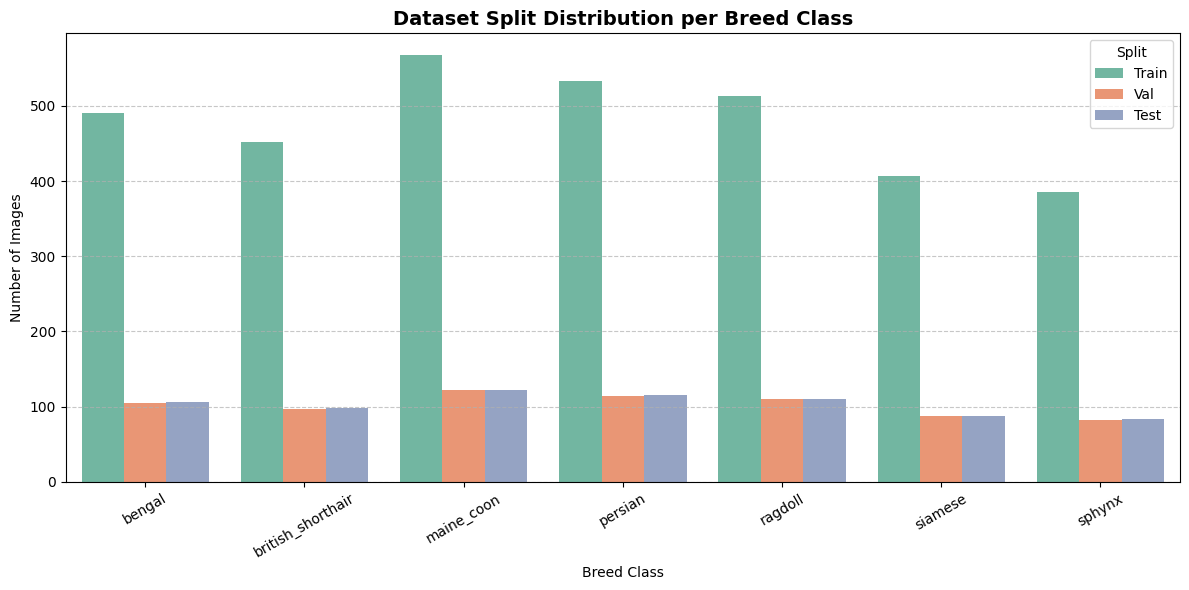

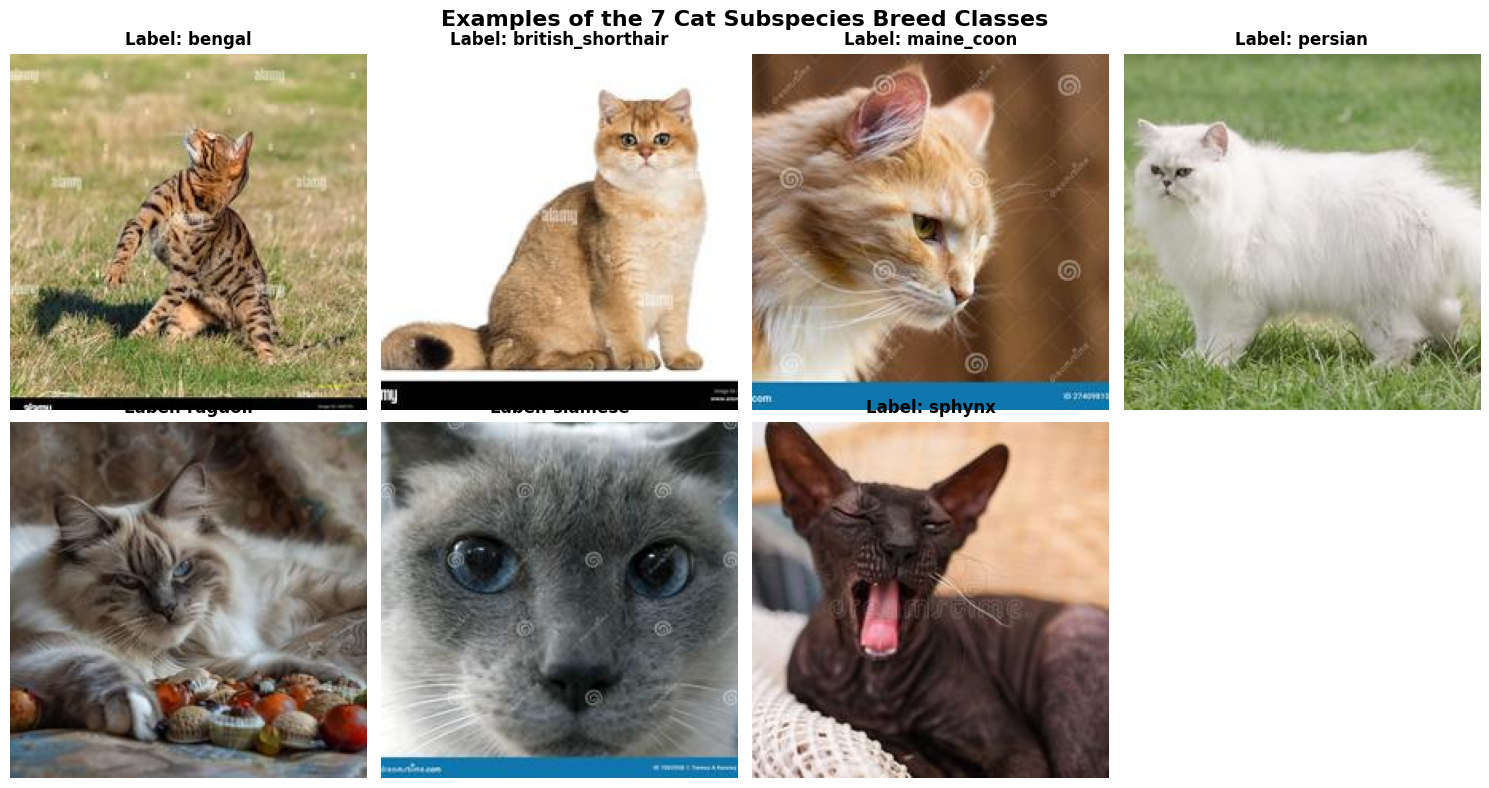

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.preprocessing import image

splits = ['train', 'val', 'test']
dataset_dir = './dataset'
classes = sorted(os.listdir(os.path.join(dataset_dir, 'train')))

dist_data = []
for split in splits:
    for cls in classes:
        path = os.path.join(dataset_dir, split, cls)
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            dist_data.append({'Split': split.capitalize(), 'Breed Class': cls, 'Image Count': count})

df_dist = pd.DataFrame(dist_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_dist, x='Breed Class', y='Image Count', hue='Split', palette='Set2')
plt.title('Dataset Split Distribution per Breed Class', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(15, 8))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(dataset_dir, 'train', cls)
    img_name = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
    img_path = os.path.join(cls_dir, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {cls}", fontsize=12, fontweight='bold')
    plt.axis('off')
plt.suptitle('Examples of the 7 Cat Subspecies Breed Classes', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('sample_classes.png', dpi=300)
plt.show()

### 6.2 Model Training History
Accuracy and loss curves for ResNet50, DenseNet121, and MobileNetV3 over 50 epochs.

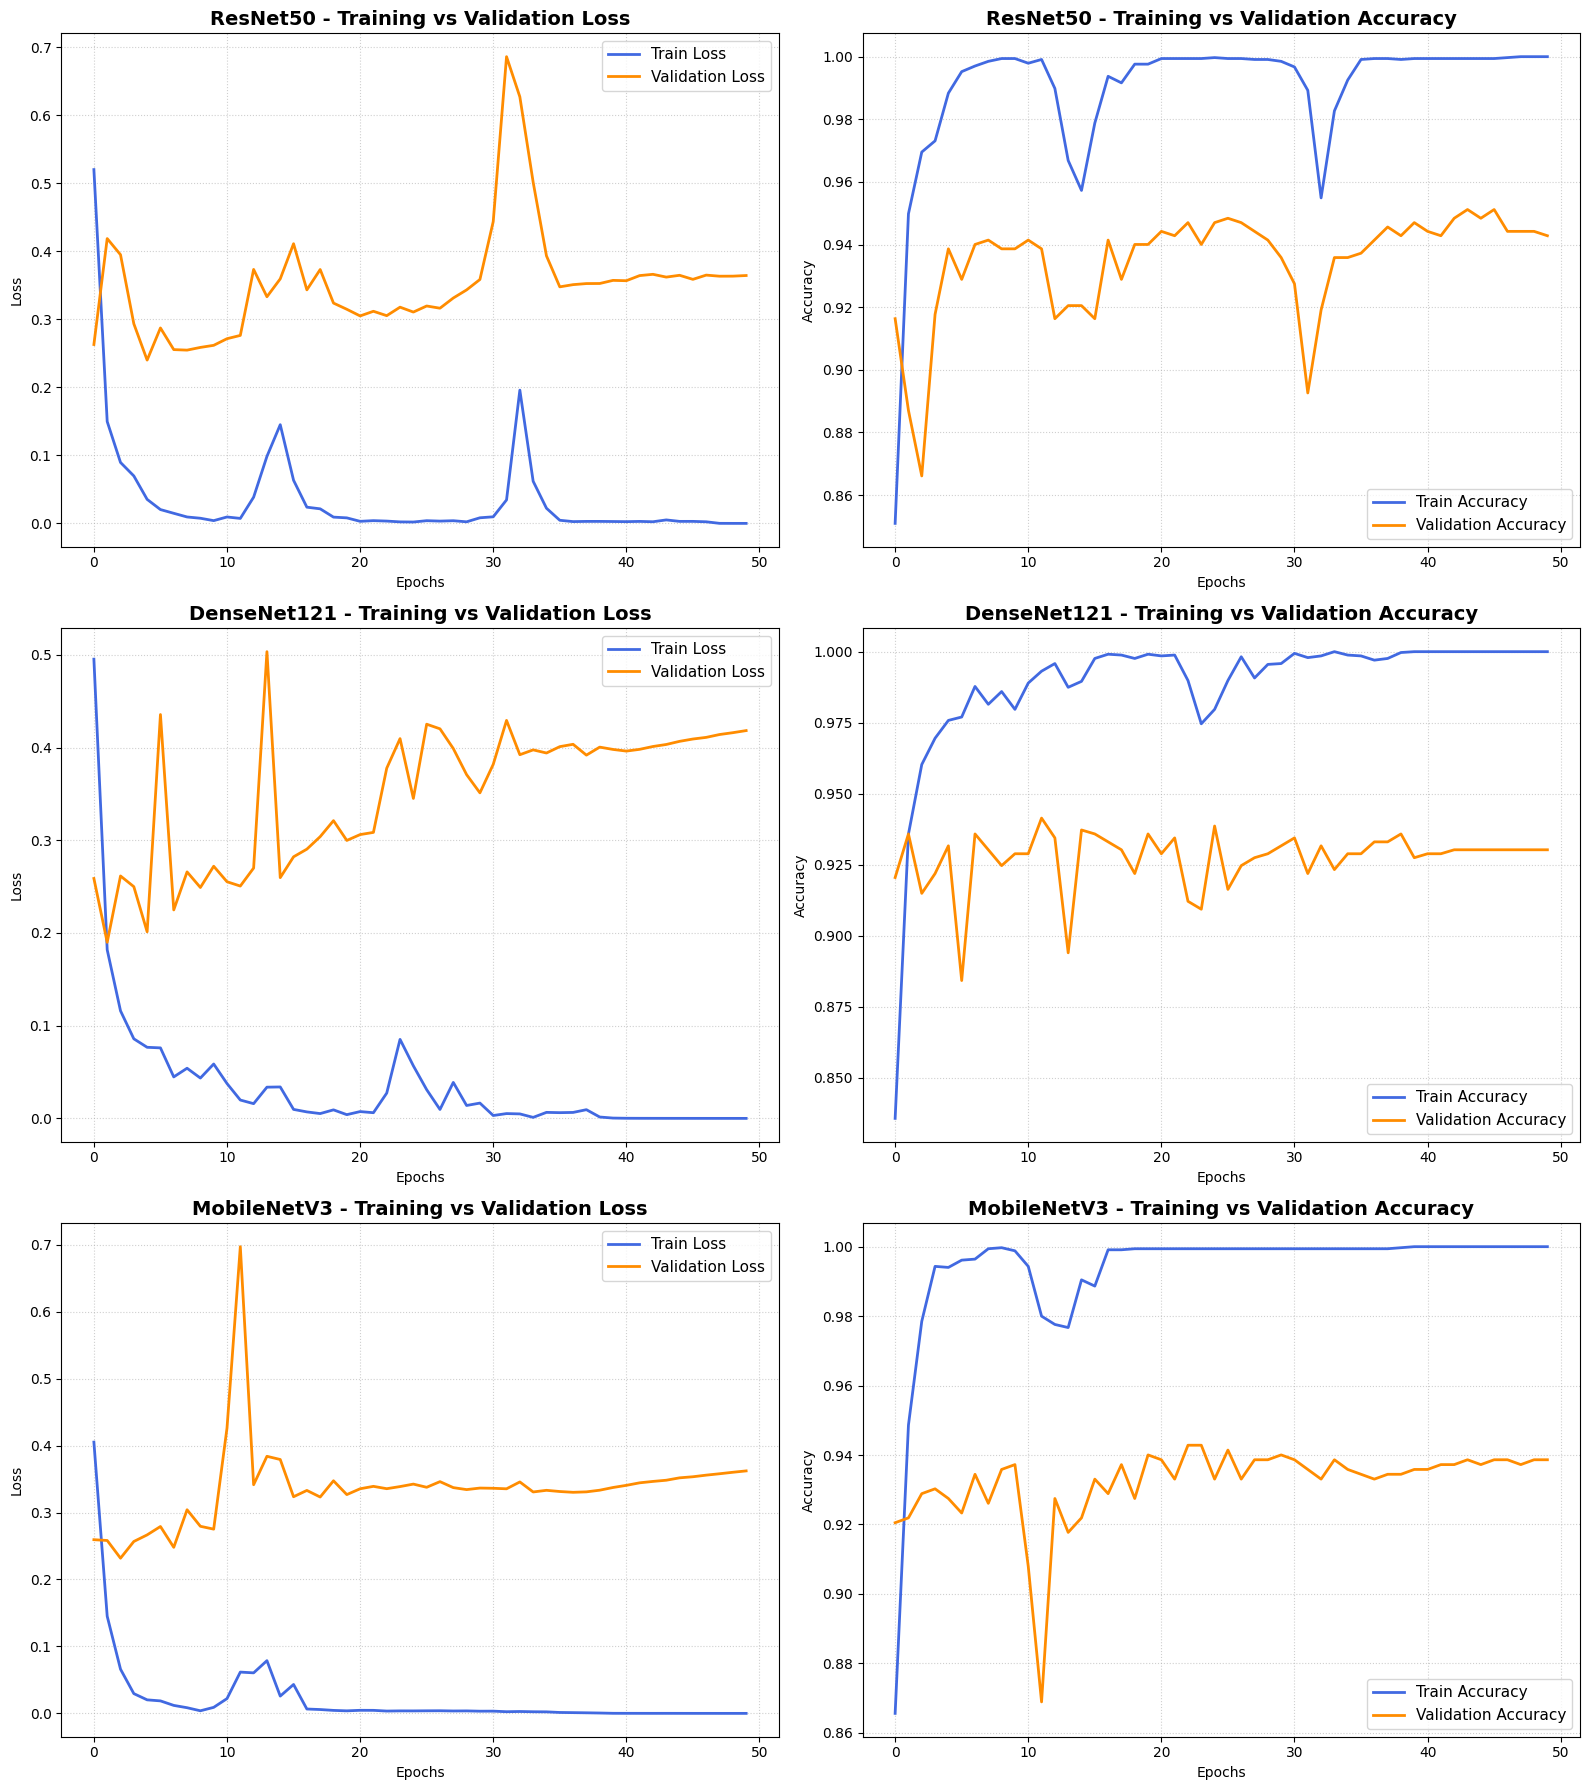

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

models = ['ResNet50', 'DenseNet121', 'MobileNetV3']
csv_paths = {}

for m in models:
    if os.path.exists(f'{m}_training_history.csv'):
        csv_paths[m] = f'{m}_training_history.csv'
    elif os.path.exists(f'logs/{m}_training_history.csv'):
        csv_paths[m] = f'logs/{m}_training_history.csv'
    else:
        print(f"Warning: History file for {m} not found!")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for idx, m in enumerate(models):
    if m not in csv_paths:
        continue
    df = pd.read_csv(csv_paths[m])

    axes[idx, 0].plot(df['epoch'], df['loss'], label='Train Loss', color='royalblue', lw=2)
    axes[idx, 0].plot(df['epoch'], df['val_loss'], label='Validation Loss', color='darkorange', lw=2)
    axes[idx, 0].set_title(f'{m} - Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[idx, 0].set_xlabel('Epochs')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend(fontsize=11)
    axes[idx, 0].grid(True, linestyle=':', alpha=0.6)

    axes[idx, 1].plot(df['epoch'], df['accuracy'], label='Train Accuracy', color='royalblue', lw=2)
    axes[idx, 1].plot(df['epoch'], df['val_accuracy'], label='Validation Accuracy', color='darkorange', lw=2)
    axes[idx, 1].set_title(f'{m} - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
    axes[idx, 1].set_xlabel('Epochs')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend(fontsize=11)
    axes[idx, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('models_training_curves.png', dpi=300)
plt.show()

### 6.3 Evaluation & Confusion Matrices
Evaluating the models on the test set and displaying confusion matrices to identify misclassifications.


Evaluating Model: ResNet50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step


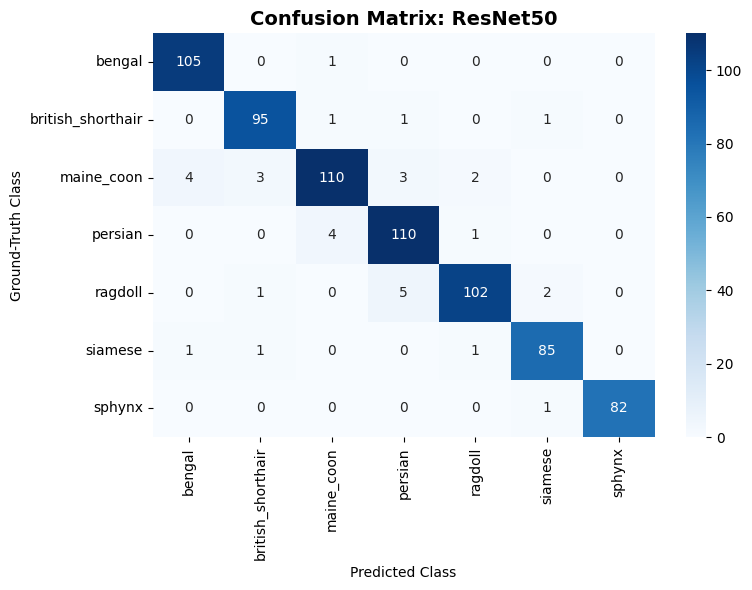

                   precision    recall  f1-score   support

           bengal       0.95      0.99      0.97       106
british_shorthair       0.95      0.97      0.96        98
       maine_coon       0.95      0.90      0.92       122
          persian       0.92      0.96      0.94       115
          ragdoll       0.96      0.93      0.94       110
          siamese       0.96      0.97      0.96        88
           sphynx       1.00      0.99      0.99        83

         accuracy                           0.95       722
        macro avg       0.96      0.96      0.96       722
     weighted avg       0.95      0.95      0.95       722


Evaluating Model: DenseNet121
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 670ms/step


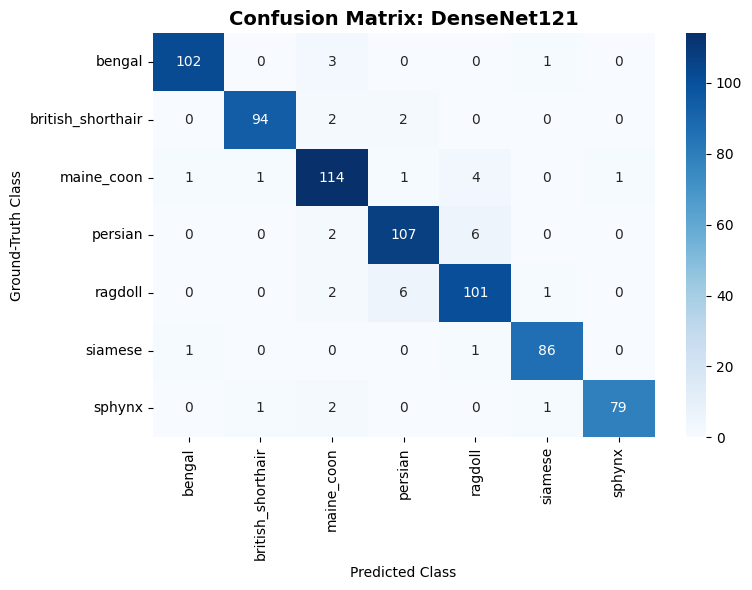

                   precision    recall  f1-score   support

           bengal       0.98      0.96      0.97       106
british_shorthair       0.98      0.96      0.97        98
       maine_coon       0.91      0.93      0.92       122
          persian       0.92      0.93      0.93       115
          ragdoll       0.90      0.92      0.91       110
          siamese       0.97      0.98      0.97        88
           sphynx       0.99      0.95      0.97        83

         accuracy                           0.95       722
        macro avg       0.95      0.95      0.95       722
     weighted avg       0.95      0.95      0.95       722


Evaluating Model: MobileNetV3
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 260ms/step


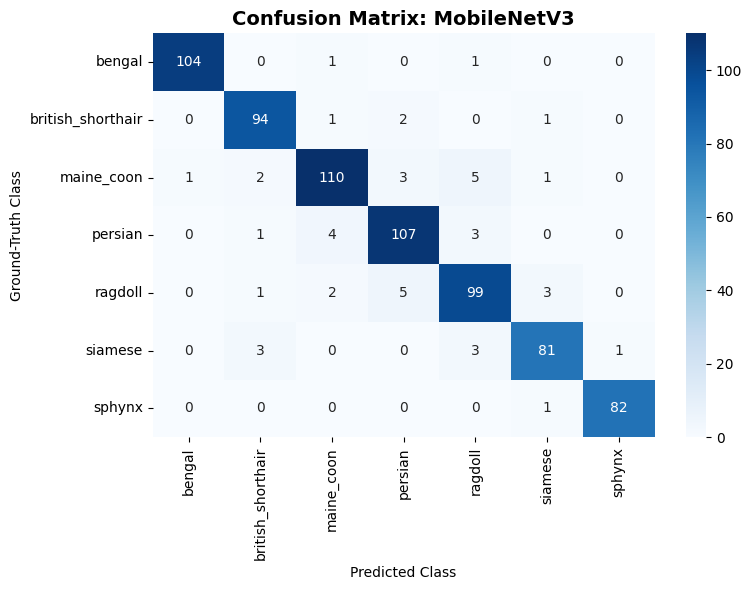

                   precision    recall  f1-score   support

           bengal       0.99      0.98      0.99       106
british_shorthair       0.93      0.96      0.94        98
       maine_coon       0.93      0.90      0.92       122
          persian       0.91      0.93      0.92       115
          ragdoll       0.89      0.90      0.90       110
          siamese       0.93      0.92      0.93        88
           sphynx       0.99      0.99      0.99        83

         accuracy                           0.94       722
        macro avg       0.94      0.94      0.94       722
     weighted avg       0.94      0.94      0.94       722



In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

# Get class names directly from the folder structure to avoid the error
class_names = sorted(os.listdir('./dataset/train'))

y_true = []
for _, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

test_evals = {}

for m in models:
    model_file = f'{m}_best_model.keras'
    if not os.path.exists(model_file):
        print(f"File {model_file} not found.")
        continue

    print(f"\nEvaluating Model: {m}")
    model = tf.keras.models.load_model(model_file)

    eval_metrics = model.evaluate(test_dataset, verbose=0)
    loss, accuracy, mAP = eval_metrics[0], eval_metrics[1], eval_metrics[2]

    predictions = model.predict(test_dataset)
    y_pred = np.argmax(predictions, axis=1)

    test_evals[m] = {
        'loss': loss,
        'accuracy': accuracy,
        'mAP': mAP,
        'y_pred': y_pred
    }

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {m}', fontsize=14, fontweight='bold')
    plt.ylabel('Ground-Truth Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig(f'{m}_confusion_matrix.png', dpi=300)
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))

### 6.4 Model Comparison & Conclusion
Summary table comparing model size, speed, and accuracy metrics.

In [ ]:
import pandas as pd

training_times = {
    'ResNet50': 9.81,      # minutes
    'DenseNet121': 9.49,   # minutes
    'MobileNetV3': 3.85    # minutes
}

summary_comparison = []

for m in models:
    model_file = f'{m}_best_model.keras'
    if not os.path.exists(model_file):
        continue

    model = tf.keras.models.load_model(model_file)
    total_params = model.count_params()

    csv_file = f'{m}_training_history.csv' if os.path.exists(f'{m}_training_history.csv') else f'logs/{m}_training_history.csv'
    df_hist = pd.read_csv(csv_file)
    best_val_acc = df_hist['val_accuracy'].max()

    summary_comparison.append({
        'Model Architecture': m,
        'Total Parameters': f"{total_params:,}",
        'Training Time (mins)': f"{training_times[m]:.2f}",
        'Best Val Accuracy': f"{best_val_acc:.4f}",
        'Test Accuracy': f"{test_evals[m]['accuracy']:.4f}",
        'Test mAP (PR-AUC)': f"{test_evals[m]['mAP']:.4f}"
    })

df_comparative = pd.DataFrame(summary_comparison)
print("\n" + "="*50)
print("             FINAL MODEL COMPARISON TABLE")
print("="*50)
display(df_comparative)


             FINAL MODEL COMPARISON TABLE


,Model Architecture,Total Parameters,Training Time (mins),Best Val Accuracy,Test Accuracy,Test mAP (PR-AUC)
0,ResNet50,"25,693,063",9.81,0.9512,0.9543,0.9795
1,DenseNet121,"8,094,279",9.49,0.9414,0.9460,0.9849
2,MobileNetV3,"3,987,591",3.85,0.9428,0.9377,0.9686
